In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.5


In [2]:
mode = deepssfp.DataMode.SuperFOV.value
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)

D:/DeepSSFP/block_phantom_superfov D:/DeepSSFP/block_phantom_dataset.npy


In [3]:
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),
    2: ('bone marrow', 0.370, 0.05, 0),
    3: ('liver', 0.8, 0.04, 0),
    4: ('white matter', 1.0, 0.08, 0),
    5: ('myocardium', 1.150, 0.045, 0),
    6: ('vessels', 1.2, 0.05, 0),   
    7: ('gray matter', 1.3, 0.110, 0),
    8: ('muscle', 1.4, 0.030, 0),
    9: ('CSF', 4.0, 1.0, 0)
}

Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (200, 128, 128, 4)


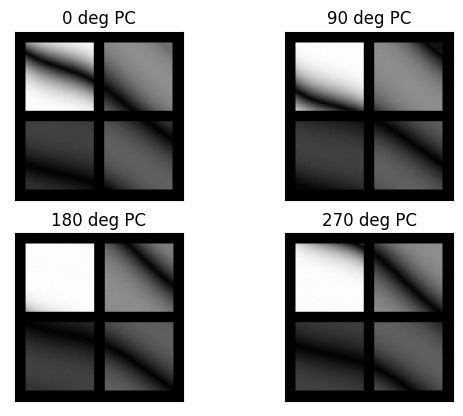

(160, 128, 128, 2) (160, 128, 128, 2)
5.483374672590626e-05 11.946578916058666 -8.231240989926078e-06 9.552178373725441
Selected indices: [38 21 32 29  5]
Figure size: (4, 10)


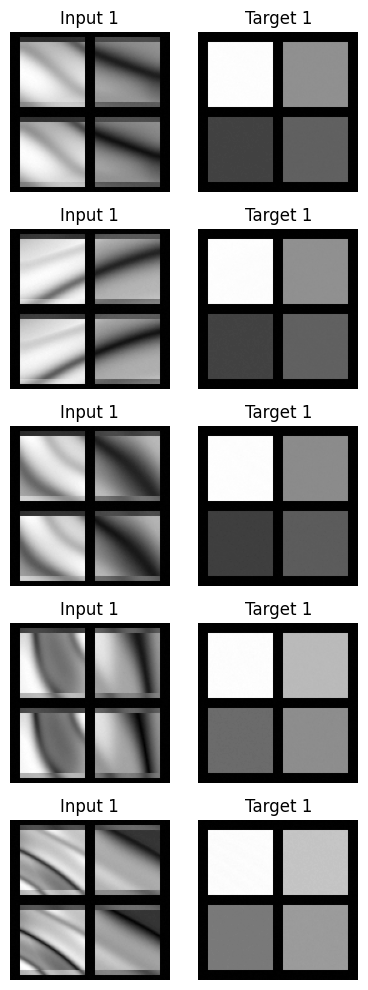

In [5]:
slices = 200
alphas = np.random.uniform(20, 60, size=slices)
alphas = np.deg2rad(alphas)
alphas = alphas[:, np.newaxis, np.newaxis]
dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4], tissues=tissue_parameters,
                                      npcs=4, f=500, alpha=alphas, sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                      fn_offset=150, rotation=90, useRotate=True, useDeform=True)

data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=5,
    kspace = True
)